<a href="https://colab.research.google.com/github/SLucy0/Data_Analytics/blob/main/Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cloning Github repository in Colab.

In [43]:
!git clone https://github.com/SLucy0/SI-Ferry-Ridership.git

fatal: destination path 'SI-Ferry-Ridership' already exists and is not an empty directory.


Check number of actual files.

In [44]:
import os

base_path = "/content/SI-Ferry-Ridership"
files = os.listdir(base_path)

len(files)

109

Quick diagnostic because file count says 109. There should be 108 files.

In [45]:
for root, dirs, files in os.walk("/content/SI-Ferry-Ridership"):
    print(root, len(files))

/content/SI-Ferry-Ridership 108
/content/SI-Ferry-Ridership/.git 5
/content/SI-Ferry-Ridership/.git/refs 0
/content/SI-Ferry-Ridership/.git/refs/heads 1
/content/SI-Ferry-Ridership/.git/refs/tags 0
/content/SI-Ferry-Ridership/.git/refs/remotes 0
/content/SI-Ferry-Ridership/.git/refs/remotes/origin 1
/content/SI-Ferry-Ridership/.git/objects 0
/content/SI-Ferry-Ridership/.git/objects/info 0
/content/SI-Ferry-Ridership/.git/objects/pack 2
/content/SI-Ferry-Ridership/.git/logs 1
/content/SI-Ferry-Ridership/.git/logs/refs 0
/content/SI-Ferry-Ridership/.git/logs/refs/heads 1
/content/SI-Ferry-Ridership/.git/logs/refs/remotes 0
/content/SI-Ferry-Ridership/.git/logs/refs/remotes/origin 1
/content/SI-Ferry-Ridership/.git/info 1
/content/SI-Ferry-Ridership/.git/branches 0
/content/SI-Ferry-Ridership/.git/hooks 13


Setting path. Reading files directly from Github.

In [46]:
import os
import pandas as pd

base_path = "/content/SI-Ferry-Ridership"
files = sorted(os.listdir(base_path))

Before using Github, Mounting Google Drive-

Connect to Google Drive and find the files.
Looks inside my Drive to confirm access.
Sets a folder path (capstone_project) where my data files live.
Gets a sorted list of all files in that folder (default, ascending order).

In [47]:
# Data source: NYC Open Data, Staten Island Ferry Ridership Counts
# url = "https://nycdot.sharepoint.com/sites/publicshare/OpenData/Forms/AllItems.aspx?id=%2Fsites%2Fpublicshare%2FOpenData%2FStaten%20Island%20Ferry%20Passenger%20Counts%20-%20by%20Month"
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)
#Confirming access
#import os
#os.listdir('/content/drive/MyDrive')

Bring in Panda analysis library.

In [48]:
import pandas as pd

Before using Github. Setting base path.

In [49]:
#base_path = "/content/drive/MyDrive/capstone_project"

Loading files-
Create an empty list (dfs) to store data from each file.
List files in Directory.

In [50]:
files = sorted(os.listdir(base_path))

Confirm the structure.

In [51]:
os.listdir("/content/SI-Ferry-Ridership")

['SIFMonthlyRidership_2020_09.xlsx',
 'SIFMonthlyRidership_2017_02.xls',
 'SIFMonthlyRidership_2021_08.xls',
 'SIFMonthlyRidership_2017_08.xls',
 'SIFMonthlyRidership_2025_06.xlsx',
 'SIFMonthlyRidership_2022_06.xls',
 'SIFMonthlyRidership_2017_03.xls',
 'SIFMonthlyRidership_2022_09.xls',
 'SIFMonthlyRidership_2021_07.xls',
 'SIFMonthlyRidership_2019_04.xls',
 'SIFMonthlyRidership_2024_02.xls',
 'SIFMonthlyRidership_2018_10.xls',
 'SIFMonthlyRidership_2022_07.xls',
 'SIFMonthlyRidership_2019_10.xls',
 'SIFMonthlyRidership_2020_07.xlsx',
 'SIFMonthlyRidership_2020_01.xls',
 'SIFMonthlyRidership_2017_06.xls',
 'SIFMonthlyRidership_2020_02.xlsx',
 'SIFMonthlyRidership_2025_07.xlsx',
 'SIFMonthlyRidership_2021_10.xls',
 'SIFMonthlyRidership_2024_08.xlsx',
 'SIFMonthlyRidership_2023_11.xls',
 'SIFMonthlyRidership_2021_09.xls',
 'SIFMonthlyRidership_2018_07.xls',
 'SIFMonthlyRidership_2023_10.xls',
 '.git',
 'SIFMonthlyRidership_2017_12.xls',
 'SIFMonthlyRidership_2017_05.xls',
 'SIFMonthlyR

Discovered that a select group of files were structured in ways that I could not identify. Used the output after running and rerunning 108 files to arrive at the list of files listed below.

In [52]:
dfs = []

#The internal structure of SIFMonthlyRidership_2019_12.xlsx
  #might have metadata, empty rows, or a very specific header format that the
  #general approach isn't capturing. SIFMonthlyRidership_2019_12.xlsx is being skipped for now,
  #preventing the data in that file from corrupting the rest of the combined data.
file_header_map = {
    'SIFMonthlyRidership_2019_12.xlsx': 0,
    'SIFMonthlyRidership_2020_02 .xlsx': 2,
    'SIFMonthlyRidership_2020_03 .xlsx': 2,
    'SIFMonthlyRidership_2020_04.xlsx': 2,
    'SIFMonthlyRidership_2020_05.xlsx': 3,
    'SIFMonthlyRidership_2020_06.xlsx': 3,
    'SIFMonthlyRidership_2020_07.xlsx': 3,
    'SIFMonthlyRidership_2020_09.xlsx': 2,
    'SIFMonthlyRidership_2020_10.xlsx': 2,
    'SIFMonthlyRidership_2020_11.xlsx': 2,
    'SIFMonthlyRidership_2020_12.xlsx': 3
}

Cleaning the data and normalizing the data.
Loop 1: Read each file. Default header is 0-indexed. Line 5 is index 4.

Defined a special map (file_header_map) for files that have weird formatting.

Loop 2: Check worksheet names. Open each file differently depending on whether it’s a CSV or an Excel file.  In Excel files, look at all available sheet names. Find the right sheet (‘TOTALS’ or ‘TOTAL’).

In [53]:
# Open the files
for file in files:
    df = None
    file_path = f"{base_path}/{file}"

    # Default header row (Excel row 5 → index 4)
    current_header_row_index = 4

    # Override header row if file is in the map
    if file in file_header_map:
        current_header_row_index = file_header_map[file]

    # Load file
    if file.endswith('.csv'):
        df = pd.read_csv(file_path, header=current_header_row_index)

    elif file.endswith(('.xls', '.xlsx')):
        try:
            # Try exact "TOTALS"
            df = pd.read_excel(file_path, sheet_name='TOTALS', header=current_header_row_index)

      # If that fails, look at all available sheet names
        except ValueError:
            try:
                xls = pd.ExcelFile(file_path)
                available_sheets = xls.sheet_names

                found_sheet_name = None

                # Look for "TOTALS" (case-insensitive)
                for sheet in available_sheets:
                    if sheet.strip().upper() == 'TOTALS':
                        found_sheet_name = sheet
                        break

                # If not found, look for "TOTAL"
                if found_sheet_name is None:
                    for sheet in available_sheets:
                        if sheet.strip().upper() == 'TOTAL':
                            found_sheet_name = sheet
                            break

                # If found, load data
                if found_sheet_name:
                    df = pd.read_excel(file_path, sheet_name=found_sheet_name, header=current_header_row_index)
                # Skip this file and move on to the next one
                # print a message explaining why file is skipped and list the sheets it does have
                else:
                    print(f"Skipping {file} (no 'TOTALS' or 'TOTAL' sheet found). Available sheets: {available_sheets}")
                    continue

            except Exception as e:
                print(f"Error checking sheets for {file}: {e}")
                print(f"Skipping {file} due to sheet error.")
                continue

        except Exception as e:
            print(f"Error reading Excel file {file}: {e}")
            continue

    # Using Panda, create new column and fill it with the value stored in old file
    if df is not None:
        df['source_file'] = file

        # Normalize column names
        df.columns = [str(col).strip().upper() for col in df.columns]

#Defining the columns to keep
        column_rename_map = {
            'DAY': 'Day',
            'DATE': 'Date',
            'WHT': 'WHT',
            'STG': 'STG',
            'COMBINED TOTAL': 'Combined',
            'COMBINED': 'Combined',
            'COMBINED TOTAL.1': 'Combined',
            'DIFFERENCE': 'Difference',
            'DIFF': 'Difference',
            'SOURCE_FILE': 'source_file'
        }
        # Apply the renaming
        df.rename(columns=column_rename_map, inplace=True)

        # Debug check for special files
        if file in file_header_map:
            print(f"DEBUG: Columns for {file}: {df.columns}")

        # Keep only desired columns
        desired_final_cols = ['Day', 'Date', 'WHT', 'STG', 'Combined', 'Difference', 'source_file']
        final_cols_to_select = [col for col in desired_final_cols if col in df.columns]
        df = df[final_cols_to_select].copy()

        # Filter valid days. Keep only valid weekday rows
        valid_days = ['SUN', 'MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT']
        if 'Day' in df.columns:
            df = df[df['Day'].astype(str).str.strip().str.upper().isin(valid_days)]

        # Convert it into a proper date format
        # Ensuring the dataframe has a proper Date column
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            invalid_count = df['Date'].isna().sum()

            # If something isn’t a valid date, replace it with “missing” (NaT)
            # Count invalid conversions
            # If there’s no Date column, print a message
            if invalid_count > 0:
                print(f"{file}: {invalid_count} invalid dates")
        else:
            print(f"'Date' column not found in {file}")

        # Convert ridership columns to numeric columns
        # Convert to integer/float
        # If 'data' can't be converted, change to Nan
        numeric_cols = ['WHT', 'STG', 'Combined', 'Difference']
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # Save the cleaned file
        dfs.append(df)

# Combine all dataframes/stack all the cleaned files into one table
combined_df = pd.concat(dfs, ignore_index=True)

'Date' column not found in SIFMonthlyRidership_2018_08.xls
DEBUG: Columns for SIFMonthlyRidership_2019_12.xlsx: Index(['UNNAMED: 0', 'DECEMBER 2019 STATEN ISLAND FERRY RIDERSHIP',
       'UNNAMED: 2', 'UNNAMED: 3', 'UNNAMED: 4', 'UNNAMED: 5', 'source_file'],
      dtype='object')
'Date' column not found in SIFMonthlyRidership_2019_12.xlsx
'Date' column not found in SIFMonthlyRidership_2020_02.xlsx
DEBUG: Columns for SIFMonthlyRidership_2020_04.xlsx: Index(['UNNAMED: 0', 'UNNAMED: 1', 'UNNAMED: 2', 'UNNAMED: 3', 'UNNAMED: 4',
       'UNNAMED: 5', 'source_file'],
      dtype='object')
'Date' column not found in SIFMonthlyRidership_2020_04.xlsx
DEBUG: Columns for SIFMonthlyRidership_2020_05.xlsx: Index(['2020-05-01 00:00:00', 'UNNAMED: 1', 'UNNAMED: 2', 'UNNAMED: 3',
       'UNNAMED: 4', 'UNNAMED: 5', 'source_file'],
      dtype='object')
'Date' column not found in SIFMonthlyRidership_2020_05.xlsx
DEBUG: Columns for SIFMonthlyRidership_2020_06.xlsx: Index(['2020-06-20 00:00:00', 'UNNAMED:

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""C

Loading first 10 rows to check for column headers beginning in 2017.

In [54]:
display(combined_df.head())
print(combined_df.columns)

,Day,Date,WHT,STG,Combined,Difference,source_file
0,SUN,2017-01-01,28267.0,20989.0,49256.0,7278.0,SIFMonthlyRidership_2017_01.xls
1,MON,2017-01-02,19276.0,16896.0,36172.0,2380.0,SIFMonthlyRidership_2017_01.xls
2,TUE,2017-01-03,29835.0,27475.0,57310.0,2360.0,SIFMonthlyRidership_2017_01.xls
3,WED,2017-01-04,38315.0,35031.0,73346.0,3284.0,SIFMonthlyRidership_2017_01.xls
4,THU,2017-01-05,33587.0,31073.0,64660.0,2514.0,SIFMonthlyRidership_2017_01.xls


Index(['Day', 'Date', 'WHT', 'STG', 'Combined', 'Difference', 'source_file'], dtype='object')


Loading last 10 rows to check for dates through then end of 2025.

In [55]:
display(combined_df.tail())
print(combined_df.columns)

,Day,Date,WHT,STG,Combined,Difference,source_file
3196,SAT,2025-12-27,18838.0,18621.0,37459.0,NaN,SIFMonthlyRidership_2025_12.xlsx
3197,SUN,2025-12-28,25009.0,24426.0,49435.0,NaN,SIFMonthlyRidership_2025_12.xlsx
3198,MON,2025-12-29,25856.0,25726.0,51582.0,NaN,SIFMonthlyRidership_2025_12.xlsx
3199,TUE,2025-12-30,32577.0,32135.0,64712.0,NaN,SIFMonthlyRidership_2025_12.xlsx
3200,WED,2025-12-31,25970.0,27109.0,53079.0,NaN,SIFMonthlyRidership_2025_12.xlsx


Index(['Day', 'Date', 'WHT', 'STG', 'Combined', 'Difference', 'source_file'], dtype='object')


Plotting Ridership Trends 2017 through 2025.

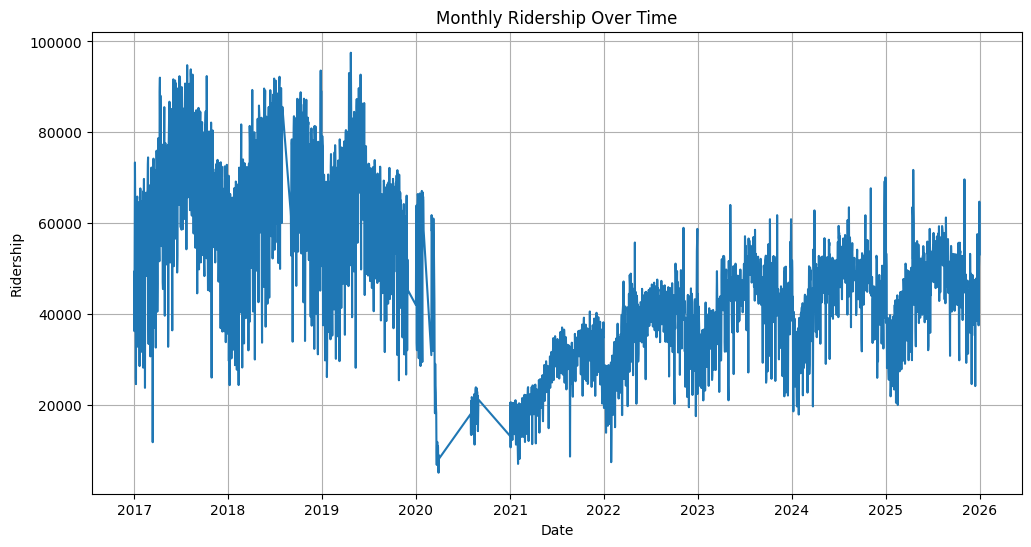

In [56]:
import matplotlib.pyplot as plt

# Ensure sorted by date
combined_df = combined_df.sort_values('Date')

# Aggregate daily totals
daily_ridership = combined_df.groupby('Date')['Combined'].sum()

plt.figure(figsize=(12,6))
plt.plot(daily_ridership)
plt.title('Monthly Ridership Over Time')
plt.xlabel('Date')
plt.ylabel('Ridership')
plt.grid()
plt.show()

Calculating the annual rolling average ridership 2017 through 2025. Good way to see long-term trends.

In [57]:
window_size = 30

rolling_avg = daily_ridership.rolling(window=window_size).mean()

# Convert to DataFrame so we can work with dates
rolling_df = rolling_avg.reset_index()
rolling_df.columns = ['Date', 'rolling_avg']

# Look at rolling_avg column, remove rows with NaN
rolling_df = rolling_df.dropna(subset=['rolling_avg'])

# Add month (year and month to avoid mixing years)
rolling_df['year_month'] = rolling_df['Date'].dt.to_period('M')

# Compute monthly average for monthly_rolling_ave
monthly_rolling_avg = (
    rolling_df.groupby('year_month')['rolling_avg']
    .mean()
    .reset_index(name='avg_rolling_ridership')
)

# Convert to integers
monthly_rolling_avg['avg_rolling_ridership'] = (
    monthly_rolling_avg['avg_rolling_ridership']
    .round(0)
    .astype('Int64')  # handles missing values safely
)

# Make month labels cleaner for display/plotting
monthly_rolling_avg['year_month'] = monthly_rolling_avg['year_month'].astype(str)

# Print results
print(f"Rolling average window size: {window_size}")
print(monthly_rolling_avg)

Rolling average window size: 30
   year_month  avg_rolling_ridership
0     2017-01                  52090
1     2017-02                  53580
2     2017-03                  56768
3     2017-04                  63098
4     2017-05                  68438
..        ...                    ...
92    2025-08                  53676
93    2025-09                  50261
94    2025-10                  47883
95    2025-11                  46376
96    2025-12                  43405

[97 rows x 2 columns]


Plotting annual rolling average ridership 2017 through 2025.

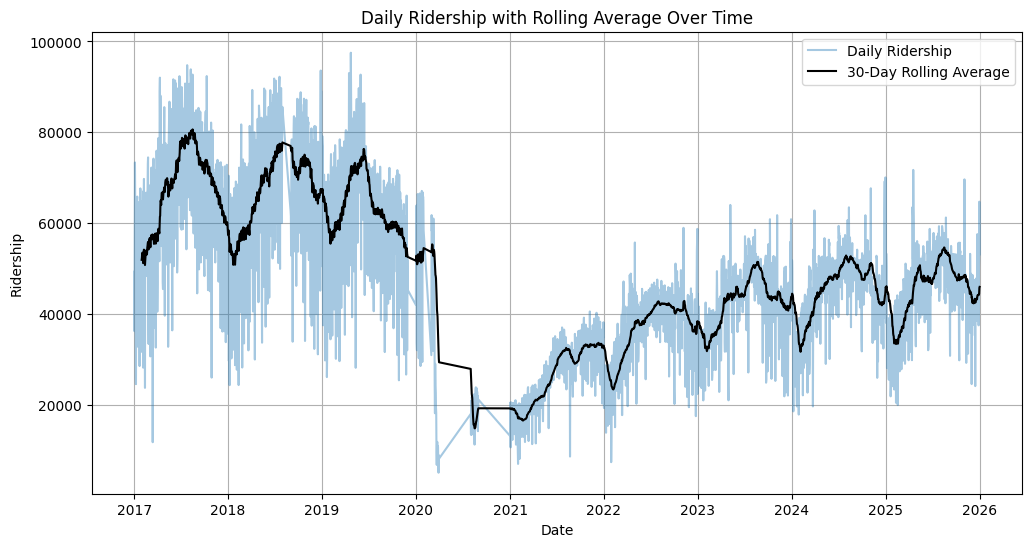

In [58]:
import matplotlib.pyplot as plt

# The daily_ridership and combined_df are already prepared from previous cells.
# window_size is also defined in a previous cell, but re-defining for clarity in this plot cell.
window_size = 30

# Calculate the rolling average
rolling_avg = daily_ridership.rolling(window=window_size).mean()

# Plotting the daily ridership and the rolling average
plt.figure(figsize=(12,6))
plt.plot(daily_ridership, alpha=0.4, label='Daily Ridership')
plt.plot(rolling_avg, color='black', label=f'{window_size}-Day Rolling Average')
plt.title('Daily Ridership with Rolling Average Over Time')
plt.xlabel('Date')
plt.ylabel('Ridership')
plt.legend()
plt.grid(True)
plt.show()

Peak Travel Day of the week, 2017 through 2025.

weekday
Monday       50797
Tuesday      58933
Wednesday    52774
Thursday     52758
Friday       53284
Saturday     42336
Sunday       36469
Name: Combined, dtype: int64


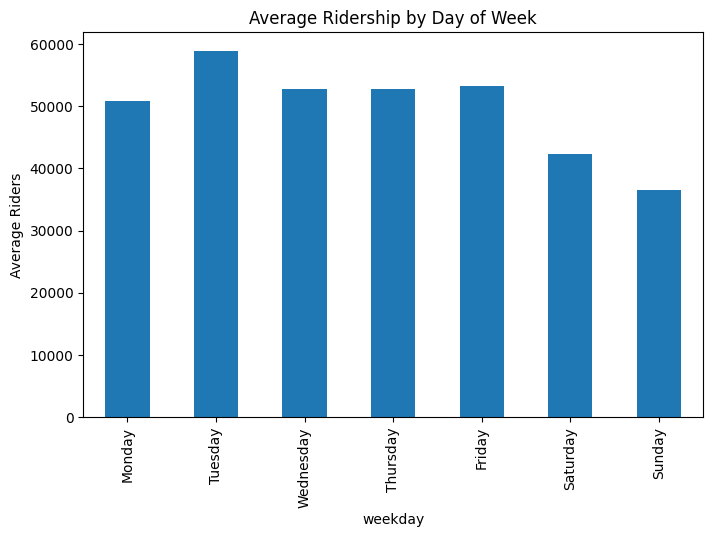

In [59]:
# Create weekday column
combined_df['weekday'] = combined_df['Date'].dt.day_name()

# Define the chronological order for weekdays
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Convert the 'weekday' column to a Categorical type with the specified order
combined_df['weekday'] = pd.Categorical(combined_df['weekday'], categories=weekday_order, ordered=True)

Ridership = combined_df.groupby('weekday', observed=False)['Combined'].mean().round(0).astype(int)

print(Ridership)

Ridership.plot(kind='bar', figsize=(8,5))
plt.title('Average Ridership by Day of Week')
plt.ylabel('Average Riders')
plt.show()

Plotting monthly ridership 2017 to 2025 to identify peak travel months.

month_name
January      40587
February     41680
March        43673
April        50703
May          53210
June         54619
July         56769
August       48503
September    52213
October      53110
November     48982
December     47322
Name: Combined, dtype: int64


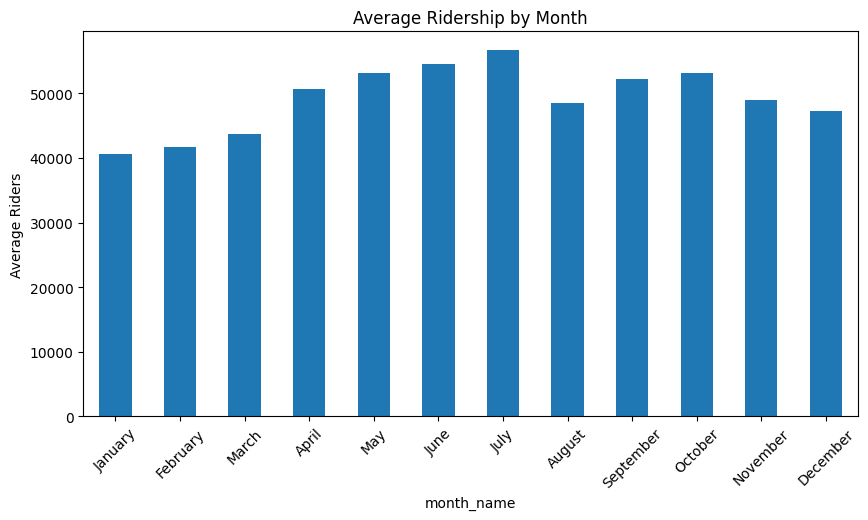

In [60]:
combined_df['month'] = combined_df['Date'].dt.month
combined_df['month_name'] = combined_df['Date'].dt.month_name()

monthly_avg = combined_df.groupby('month_name')['Combined'].mean()

# Reordering categorical type in chronological order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_avg = monthly_avg.reindex(month_order)

print(monthly_avg.round(0).astype(int))

monthly_avg.plot(kind='bar', figsize=(10,5))
plt.title('Average Ridership by Month')
plt.ylabel('Average Riders')
plt.xticks(rotation=45)
plt.show()

Comparing Pre/Post COVID ferry ridership.

In [61]:
covid_start = '2020-03-01'

pre_covid = combined_df[combined_df['Date'] < covid_start]
covid_post_covid = combined_df[combined_df['Date'] >= covid_start]

print("Pre-COVID avg:", pre_covid['Combined'].mean().round(0).astype(int))
print("COVID/Post-COVID avg:", covid_post_covid['Combined'].mean().round(0).astype(int))

Pre-COVID avg: 65240
COVID/Post-COVID avg: 39293


Plotting pre/post Covid ferry ridership in a bar chart.

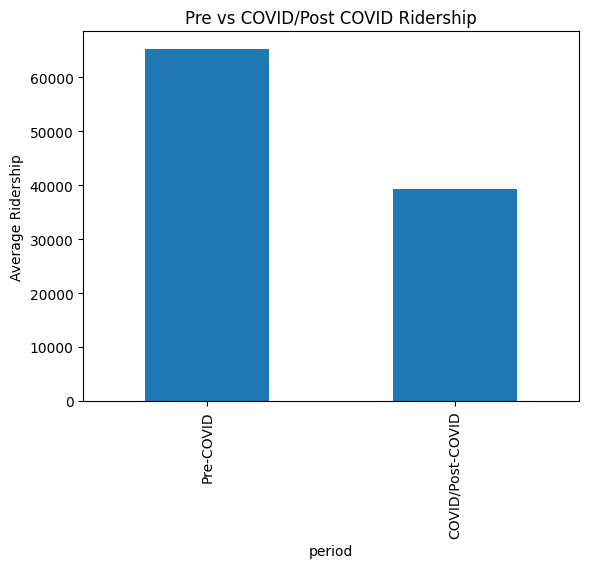

In [62]:
# Create a function to create a Pre-Covid column and a COVID/Post COVID Column
combined_df['period'] = combined_df['Date'].apply(
    lambda x: 'Pre-COVID' if x < pd.to_datetime(covid_start) else 'COVID/Post-COVID'
)

# Define the chronological order for the 'period' column
period_order = ['Pre-COVID', 'COVID/Post-COVID']

# Convert the 'period' column to a categorical type with the specified order
combined_df['period'] = pd.Categorical(combined_df['period'], categories=period_order, ordered=True)

combined_df.groupby('period', observed=False)['Combined'].mean().plot(kind='bar')
plt.title('Pre vs COVID/Post COVID Ridership')
plt.ylabel('Average Ridership')
plt.show()

Comparing ferry ridership over presidential terms (Trump vs Biden vs Trump again).

In [63]:
#Defining time periods by presidential terms
def label_president(date):
    if pd.to_datetime('2017-01-20') <= date <= pd.to_datetime('2021-01-20'):
        return 'Trump (1st Term)'
    elif pd.to_datetime('2021-01-20') < date <= pd.to_datetime('2025-01-20'):
        return 'Biden'
    elif date > pd.to_datetime('2025-01-20'):
        return 'Trump (2nd Term)'
    else:
        return 'Pre-Trump'

combined_df['president'] = combined_df['Date'].apply(label_president)

Plotting average ferry ridership by presidential term.

president
Pre-Trump           52318
Trump (1st Term)    62479
Biden               38529
Trump (2nd Term)    46192
Name: Combined, dtype: int64


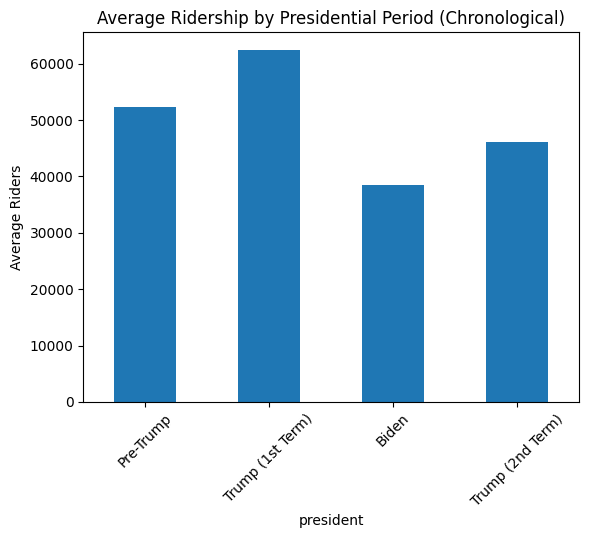

In [64]:
pres_summary = combined_df.groupby('president')['Combined'].mean()

# Define the chronological order for presidential terms
chronological_order = ['Pre-Trump', 'Trump (1st Term)', 'Biden', 'Trump (2nd Term)']

# Reindex the pres_summary series to reflect the chronological order
pres_summary_ordered = pres_summary.reindex(chronological_order)

# Print the integers plotted for each presidential term
print(pres_summary_ordered.round(0).astype(int))

# Plot average ferry ridership by presidential term, in chronological order
pres_summary_ordered.plot(kind='bar')
plt.title('Average Ridership by Presidential Period (Chronological)')
plt.ylabel('Average Riders')
plt.xticks(rotation=45) # Rotate labels for better readability if needed
plt.show()

Plotting average ferry ridership by presidential term using Seaborn and Matplotlib.

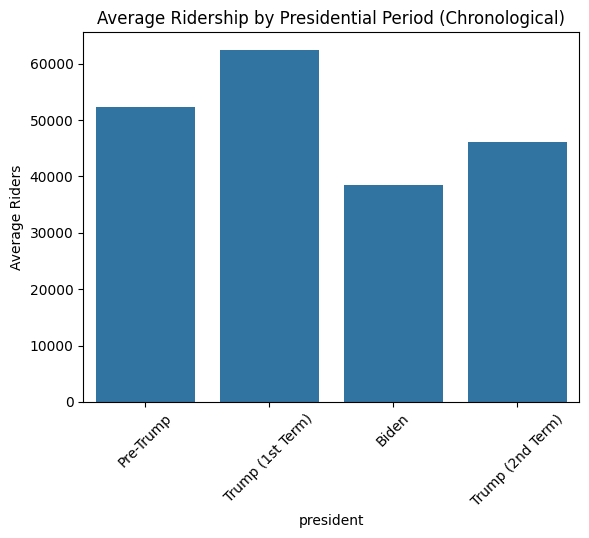

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate pres_summary, round it to 0 decimal places, and convert to integer
pres_summary_rounded = combined_df.groupby('president')['Combined'].mean().round(0).astype(int)

# Define the chronological order for presidential terms
chronological_order = ['Pre-Trump', 'Trump (1st Term)', 'Biden', 'Trump (2nd Term)']

# Reindex the pres_summary_rounded Series to reflect the chronological order
pres_summary_rounded_ordered = pres_summary_rounded.reindex(chronological_order)

sns.barplot(
    x=pres_summary_rounded_ordered.index, # Use the president names as x-axis labels
    y=pres_summary_rounded_ordered.values # Use the rounded average ridership as y-axis values
)

plt.title('Average Ridership by Presidential Period (Chronological)')
plt.ylabel('Average Riders') # Re-adding ylabel for clarity
plt.xticks(rotation=45)
plt.show()